# 02 — Exploratory Data Analysis (EDA)
## Decision Intelligence System · Olist E-Commerce Dataset

**Objective:** Explore the master dataset visually and statistically to uncover patterns, trends, and business insights across:
- Revenue & order trends over time
- Geographic distribution of sales
- Product category performance
- Delivery performance
- Customer review patterns
- Payment behaviour

**Input:** `master_olist.csv` from Notebook 01  
**Output:** 10+ charts saved to `outputs/` folder

---

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
warnings.filterwarnings('ignore')

# Paths
DATA_PATH    = '../data/'
OUTPUTS_PATH = '../outputs/'
os.makedirs(DATA_PATH,    exist_ok=True)
os.makedirs(OUTPUTS_PATH, exist_ok=True)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize']    = (13, 5)
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.3

# Consistent color palette
BLUE   = '#378ADD'
GREEN  = '#1D9E75'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
PURPLE = '#7F77DD'
COLORS = [BLUE, GREEN, AMBER, CORAL, PURPLE]

print('Setup complete!')

Setup complete!


## 2. Load Master Dataset

In [2]:
master = pd.read_csv(DATA_PATH + 'master_olist.csv', low_memory=False)

# Re-parse date columns
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    master[col] = pd.to_datetime(master[col], errors='coerce')

# Re-create time columns
master['order_month']     = master['order_purchase_timestamp'].dt.to_period('M')
master['order_month_str'] = master['order_purchase_timestamp'].dt.strftime('%Y-%m')
master['order_year']      = master['order_purchase_timestamp'].dt.year
master['order_dow']       = master['order_purchase_timestamp'].dt.day_name()
master['order_hour']      = master['order_purchase_timestamp'].dt.hour

print(f'Master dataset loaded: {master.shape[0]:,} rows × {master.shape[1]} columns')
print(f'Date range: {master["order_purchase_timestamp"].min().date()} → {master["order_purchase_timestamp"].max().date()}')
master.head(3)

Master dataset loaded: 113,425 rows × 44 columns
Date range: 2016-09-04 → 2018-10-17


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,total_payment,payment_type,max_installments,review_score,profit_proxy,delivery_delay_days,actual_delivery_days,is_late,order_month,order_year,order_dow,freight_ratio,order_month_str,order_hour
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,9350.00,maua,SP,38.71,voucher,1.00,4.00,21.27,-8.00,8.00,0,2017-10,2017,Monday,0.29,2017-10,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,31570.00,belo horizonte,SP,141.46,boleto,1.00,4.00,95.94,-6.00,13.00,0,2018-07,2018,Tuesday,0.19,2018-07,20
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,14840.00,guariba,SP,179.12,credit_card,3.00,5.00,140.68,-18.00,9.00,0,2018-08,2018,Wednesday,0.12,2018-08,8


## 3. High-Level KPI Summary

Before any charts, we establish the headline numbers — this is what goes on the executive dashboard.

In [3]:
delivered = master[master['order_status'] == 'delivered'].copy()

total_revenue    = delivered['total_payment'].sum()
total_orders     = delivered['order_id'].nunique()
total_customers  = delivered['customer_unique_id'].nunique()
total_sellers    = delivered['seller_id'].nunique()
avg_order_value  = total_revenue / total_orders
avg_review       = delivered['review_score'].mean()
on_time_rate     = (delivered['delivery_delay_days'] <= 0).mean() * 100
avg_delivery_days= delivered['actual_delivery_days'].mean()

print('=' * 50)
print('         OLIST — KEY BUSINESS METRICS')
print('=' * 50)
print(f'  Total Revenue        : R$ {total_revenue:>12,.2f}')
print(f'  Total Orders         : {total_orders:>12,}')
print(f'  Unique Customers     : {total_customers:>12,}')
print(f'  Active Sellers       : {total_sellers:>12,}')
print(f'  Avg Order Value      : R$ {avg_order_value:>11,.2f}')
print(f'  Avg Review Score     : {avg_review:>12.2f} / 5.0')
print(f'  On-Time Delivery     : {on_time_rate:>11.1f}%')
print(f'  Avg Delivery Days    : {avg_delivery_days:>11.1f} days')
print('=' * 50)

         OLIST — KEY BUSINESS METRICS
  Total Revenue        : R$ 19,776,160.44
  Total Orders         :       96,478
  Unique Customers     :       93,358
  Active Sellers       :        2,970
  Avg Order Value      : R$      204.98
  Avg Review Score     :         4.08 / 5.0
  On-Time Delivery     :        93.4%
  Avg Delivery Days    :        12.0 days


## 4. Chart 1 — Monthly Revenue & Order Trend

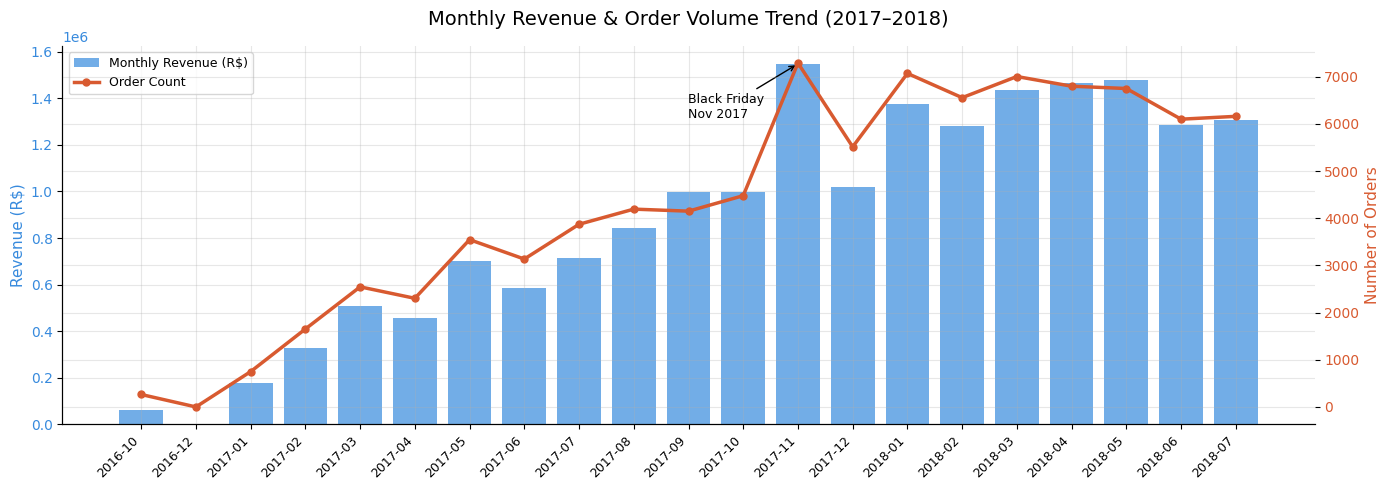

Chart saved!


In [4]:
monthly = (
    delivered
    .groupby('order_month_str')
    .agg(
        revenue      = ('total_payment', 'sum'),
        order_count  = ('order_id', 'nunique'),
        avg_order_val= ('total_payment', 'mean')
    )
    .reset_index()
    .sort_values('order_month_str')
)

# Remove first and last months (incomplete data)
monthly = monthly.iloc[1:-1].reset_index(drop=True)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly['order_month_str'], monthly['revenue'],
        color=BLUE, alpha=0.7, label='Monthly Revenue (R$)')
ax1.set_ylabel('Revenue (R$)', color=BLUE, fontsize=11)
ax1.tick_params(axis='y', labelcolor=BLUE)
ax1.set_xlabel('')
plt.xticks(rotation=45, ha='right', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(monthly['order_month_str'], monthly['order_count'],
         color=CORAL, linewidth=2.5, marker='o', markersize=5, label='Order Count')
ax2.set_ylabel('Number of Orders', color=CORAL, fontsize=11)
ax2.tick_params(axis='y', labelcolor=CORAL)

# Annotate the Nov 2017 Black Friday spike
peak_idx = monthly['revenue'].idxmax()
ax1.annotate('Black Friday\nNov 2017',
             xy=(monthly.loc[peak_idx, 'order_month_str'], monthly.loc[peak_idx, 'revenue']),
             xytext=(peak_idx - 2, monthly['revenue'].max() * 0.85),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='black')

ax1.set_title('Monthly Revenue & Order Volume Trend (2017–2018)', fontsize=14, pad=15)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'monthly_revenue_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

**Insight:** Revenue grew consistently from early 2017 to mid-2018. The November 2017 spike confirms strong Black Friday sales. Growth flattened in mid-2018 — worth monitoring for seasonality vs. market saturation.

## 5. Chart 2 — Order Status Breakdown

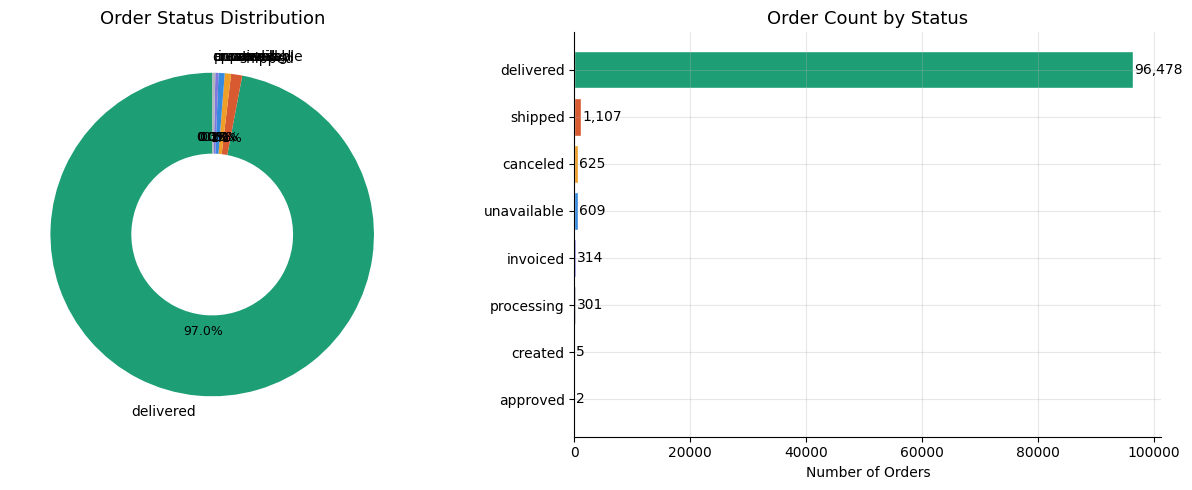

Chart saved!


In [5]:
status_counts = master.drop_duplicates('order_id')['order_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Donut chart
colors_status = [GREEN, CORAL, AMBER, BLUE, PURPLE, '#adb5bd', '#6c757d']
wedges, texts, autotexts = axes[0].pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors_status[:len(status_counts)],
    startangle=90,
    wedgeprops=dict(width=0.5)
)
for at in autotexts:
    at.set_fontsize(9)
axes[0].set_title('Order Status Distribution', fontsize=13)

# Bar chart with counts
bars = axes[1].barh(status_counts.index, status_counts.values,
                    color=colors_status[:len(status_counts)], edgecolor='white')
for bar, val in zip(bars, status_counts.values):
    axes[1].text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)
axes[1].set_title('Order Count by Status', fontsize=13)
axes[1].set_xlabel('Number of Orders')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'order_status_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## 6. Chart 3 — Top 15 Product Categories by Revenue

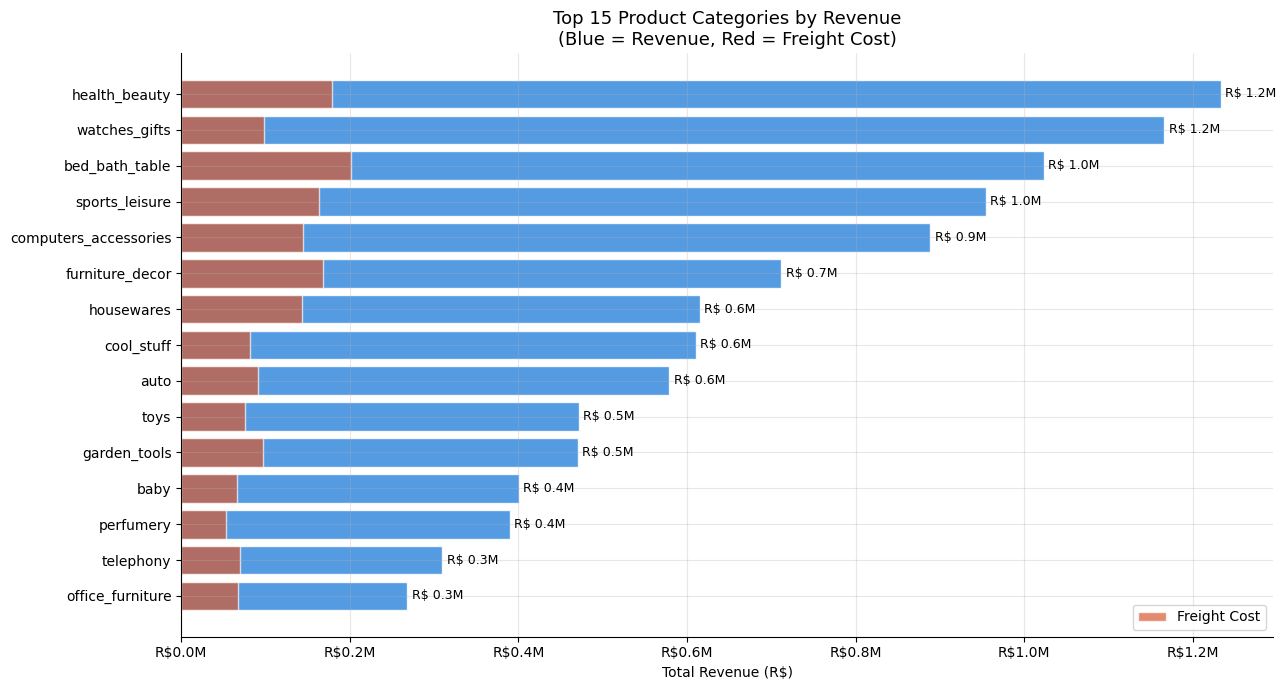

Chart saved!

Top 5 by Revenue:
   product_category_name_english  total_revenue  freight_ratio  avg_review
43                 health_beauty     1233131.72          14.50        4.19
70                 watches_gifts     1166176.98           8.40        4.07
7                 bed_bath_table     1023434.76          19.70        3.92
65                sports_leisure      954852.55          17.10        4.17
15         computers_accessories      888724.61          16.20        3.99


In [6]:
category_rev = (
    delivered
    .groupby('product_category_name_english')
    .agg(
        total_revenue  = ('price', 'sum'),
        total_freight  = ('freight_value', 'sum'),
        order_count    = ('order_id', 'nunique'),
        avg_review     = ('review_score', 'mean')
    )
    .reset_index()
)
category_rev['profit_proxy']    = category_rev['total_revenue'] - category_rev['total_freight']
category_rev['freight_ratio']   = (category_rev['total_freight'] / category_rev['total_revenue'] * 100).round(1)
category_rev = category_rev.dropna(subset=['product_category_name_english'])
top15_rev = category_rev.nlargest(15, 'total_revenue')

fig, ax = plt.subplots(figsize=(13, 7))
bars = ax.barh(top15_rev['product_category_name_english'],
               top15_rev['total_revenue'],
               color=BLUE, alpha=0.85, edgecolor='white')

# Overlay freight in red
ax.barh(top15_rev['product_category_name_english'],
        top15_rev['total_freight'],
        color=CORAL, alpha=0.7, edgecolor='white', label='Freight Cost')

for bar, val in zip(bars, top15_rev['total_revenue']):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2,
            f'R$ {val/1e6:.1f}M', va='center', fontsize=9)

ax.set_title('Top 15 Product Categories by Revenue\n(Blue = Revenue, Red = Freight Cost)', fontsize=13)
ax.set_xlabel('Total Revenue (R$)')
ax.invert_yaxis()
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'top15_categories_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print('\nTop 5 by Revenue:')
print(top15_rev[['product_category_name_english','total_revenue','freight_ratio','avg_review']].head())

**Insight:** Health & Beauty leads in revenue with relatively low freight ratio — high margin category. Bed/Bath/Table and Computers & Accessories are also strong. Categories with high freight ratio (red bar = large % of blue) are profit risks.

## 7. Chart 4 — Revenue by Brazilian State

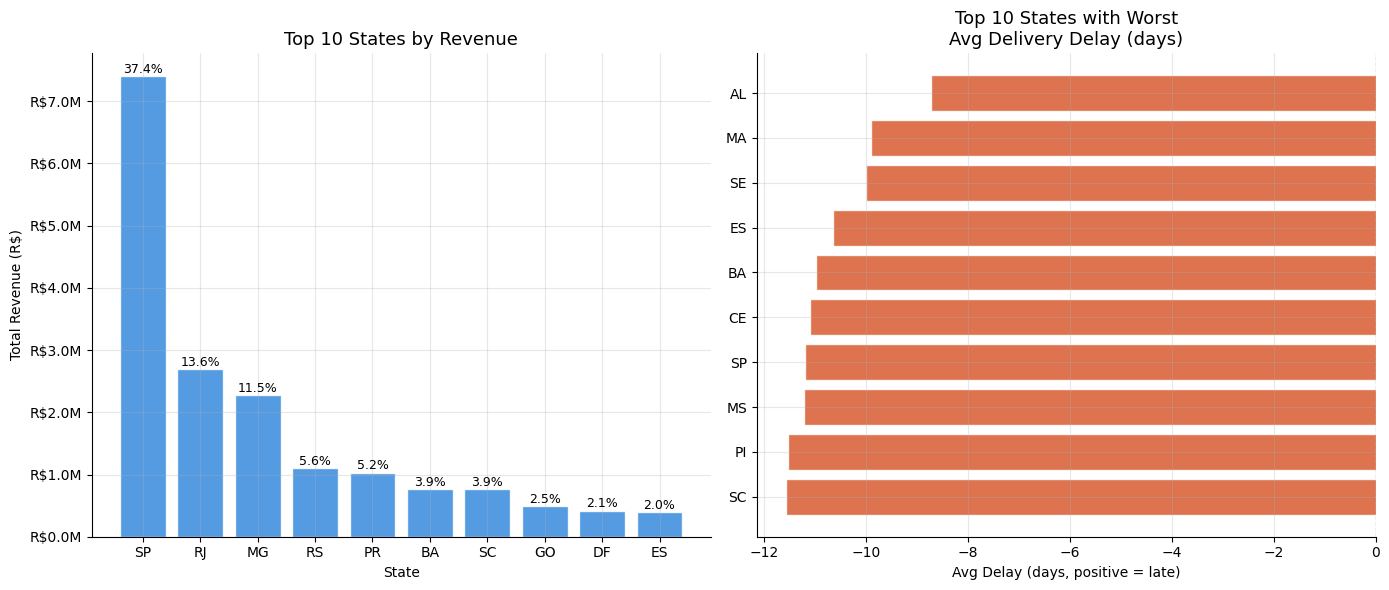

Chart saved!

SP accounts for 37.4% of total revenue


In [7]:
state_rev = (
    delivered
    .groupby('customer_state')
    .agg(
        total_revenue = ('total_payment', 'sum'),
        order_count   = ('order_id', 'nunique'),
        avg_review    = ('review_score', 'mean'),
        avg_delay     = ('delivery_delay_days', 'mean')
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
state_rev['revenue_pct'] = (state_rev['total_revenue'] / state_rev['total_revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 10 states bar chart
top10_states = state_rev.head(10)
bars = axes[0].bar(top10_states['customer_state'], top10_states['total_revenue'],
                   color=BLUE, alpha=0.85, edgecolor='white')
for bar, pct in zip(bars, top10_states['revenue_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
                 f'{pct}%', ha='center', fontsize=9)
axes[0].set_title('Top 10 States by Revenue', fontsize=13)
axes[0].set_xlabel('State')
axes[0].set_ylabel('Total Revenue (R$)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1e6:.1f}M'))

# Avg delivery delay by state (bottom 10)
worst_delay = state_rev.nlargest(10, 'avg_delay')
axes[1].barh(worst_delay['customer_state'], worst_delay['avg_delay'],
             color=CORAL, alpha=0.85, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Top 10 States with Worst\nAvg Delivery Delay (days)', fontsize=13)
axes[1].set_xlabel('Avg Delay (days, positive = late)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'revenue_and_delay_by_state.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f"\nSP accounts for {state_rev[state_rev['customer_state']=='SP']['revenue_pct'].values[0]}% of total revenue")

## 8. Chart 5 — Delivery Performance Analysis

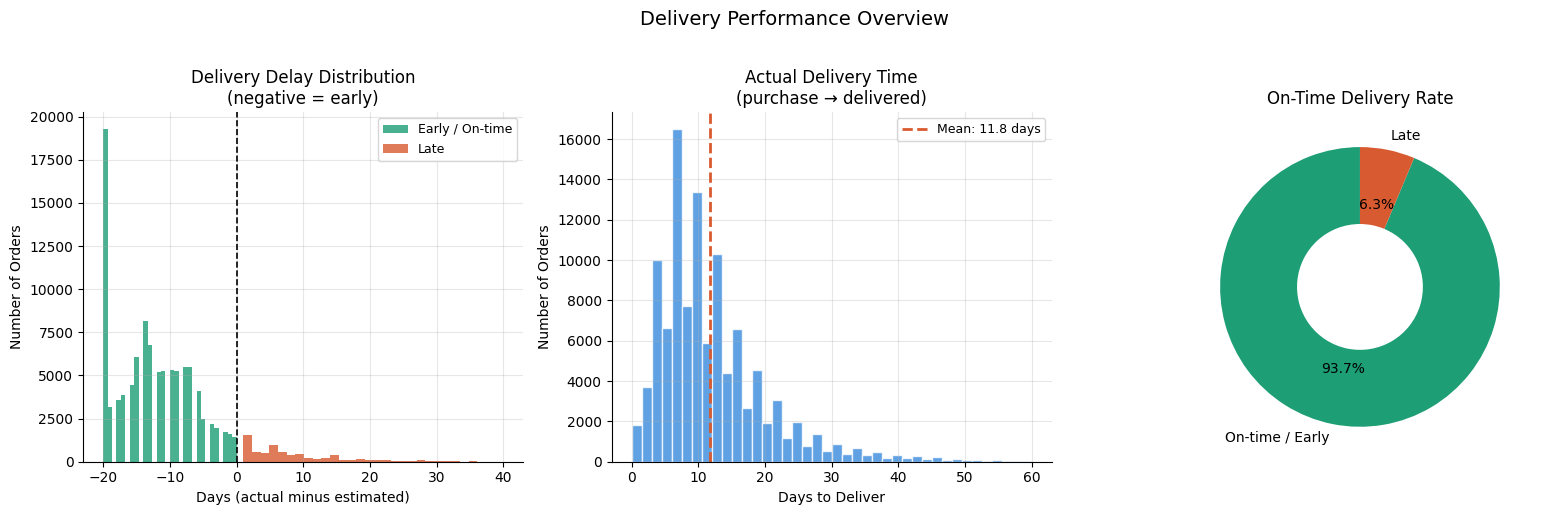

Chart saved!
On-time rate : 93.7%
Average delay: -12.2 days


In [8]:
delivery_data = delivered.dropna(subset=['delivery_delay_days', 'actual_delivery_days']).copy()
delivery_data = delivery_data[delivery_data['actual_delivery_days'].between(0, 60)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Delivery delay distribution
delay_clip = delivery_data['delivery_delay_days'].clip(-20, 40)
axes[0].hist(delay_clip[delay_clip <= 0], bins=30, color=GREEN,
             alpha=0.8, label='Early / On-time')
axes[0].hist(delay_clip[delay_clip > 0], bins=30, color=CORAL,
             alpha=0.8, label='Late')
axes[0].axvline(0, color='black', linewidth=1.2, linestyle='--')
axes[0].set_title('Delivery Delay Distribution\n(negative = early)', fontsize=12)
axes[0].set_xlabel('Days (actual minus estimated)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend(fontsize=9)

# Actual delivery days histogram
axes[1].hist(delivery_data['actual_delivery_days'], bins=40,
             color=BLUE, alpha=0.8, edgecolor='white')
axes[1].axvline(delivery_data['actual_delivery_days'].mean(), color=CORAL,
                linewidth=2, linestyle='--',
                label=f"Mean: {delivery_data['actual_delivery_days'].mean():.1f} days")
axes[1].set_title('Actual Delivery Time\n(purchase → delivered)', fontsize=12)
axes[1].set_xlabel('Days to Deliver')
axes[1].set_ylabel('Number of Orders')
axes[1].legend(fontsize=9)

# On-time vs late pie
on_time_count = (delivery_data['delivery_delay_days'] <= 0).sum()
late_count    = (delivery_data['delivery_delay_days'] > 0).sum()
axes[2].pie([on_time_count, late_count],
            labels=['On-time / Early', 'Late'],
            autopct='%1.1f%%',
            colors=[GREEN, CORAL],
            startangle=90,
            wedgeprops=dict(width=0.55))
axes[2].set_title('On-Time Delivery Rate', fontsize=12)

plt.suptitle('Delivery Performance Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'delivery_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f"On-time rate : {on_time_count/(on_time_count+late_count)*100:.1f}%")
print(f"Average delay: {delivery_data['delivery_delay_days'].mean():.1f} days")

## 9. Chart 6 — Review Score vs Delivery Delay

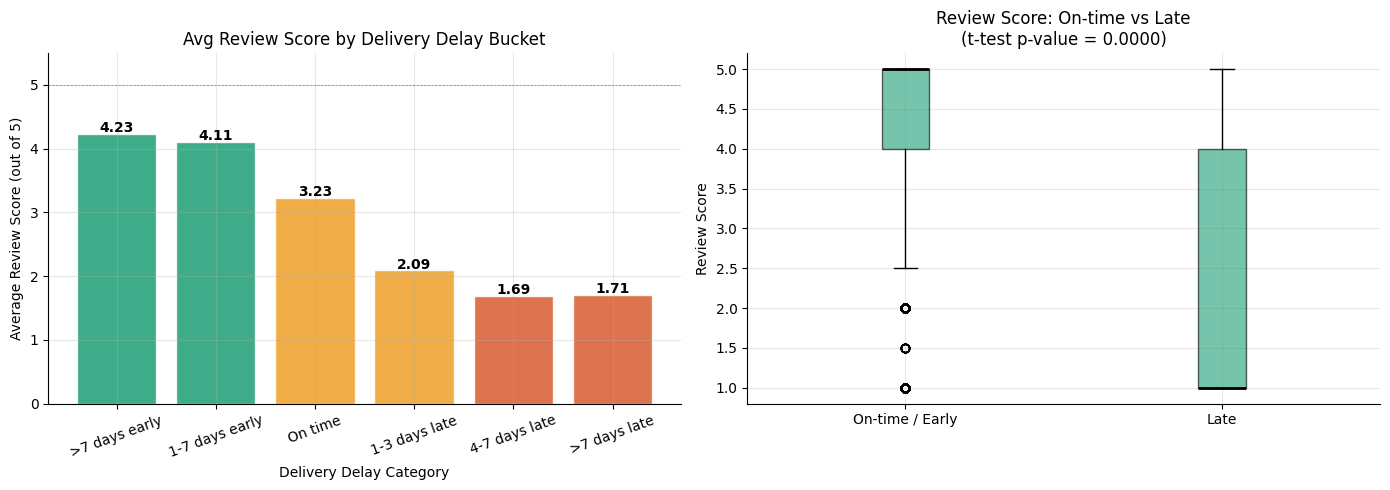

On-time avg review : 4.21
Late avg review    : 2.26
Difference         : 1.95 stars
P-value            : 0.000000 — STATISTICALLY SIGNIFICANT


In [9]:
from scipy import stats

review_delay = delivered.dropna(subset=['review_score', 'delivery_delay_days']).copy()
review_delay['delay_bucket'] = pd.cut(
    review_delay['delivery_delay_days'],
    bins=[-999, -7, 0, 3, 7, 14, 999],
    labels=['>7 days early', '1-7 days early', 'On time',
            '1-3 days late', '4-7 days late', '>7 days late']
)

bucket_review = (
    review_delay
    .groupby('delay_bucket', observed=True)
    .agg(
        avg_review  = ('review_score', 'mean'),
        order_count = ('order_id', 'count')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg review by delay bucket
bar_colors = [GREEN, GREEN, AMBER, AMBER, CORAL, CORAL]
bars = axes[0].bar(bucket_review['delay_bucket'], bucket_review['avg_review'],
                   color=bar_colors, edgecolor='white', alpha=0.85)
for bar, val in zip(bars, bucket_review['avg_review']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                 f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Avg Review Score by Delivery Delay Bucket', fontsize=12)
axes[0].set_xlabel('Delivery Delay Category')
axes[0].set_ylabel('Average Review Score (out of 5)')
axes[0].set_ylim(0, 5.5)
axes[0].tick_params(axis='x', rotation=20)
axes[0].axhline(5, color='gray', linewidth=0.5, linestyle='--')

# Statistical test: on-time vs late
on_time_reviews = review_delay[review_delay['delivery_delay_days'] <= 0]['review_score']
late_reviews    = review_delay[review_delay['delivery_delay_days'] >  0]['review_score']
t_stat, p_val   = stats.ttest_ind(on_time_reviews, late_reviews)

axes[1].boxplot(
    [on_time_reviews, late_reviews],
    labels=['On-time / Early', 'Late'],
    patch_artist=True,
    boxprops=dict(facecolor=GREEN, alpha=0.6),
    medianprops=dict(color='black', linewidth=2)
)
axes[1].set_title(f'Review Score: On-time vs Late\n(t-test p-value = {p_val:.4f})', fontsize=12)
axes[1].set_ylabel('Review Score')

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'review_vs_delay.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"On-time avg review : {on_time_reviews.mean():.2f}")
print(f"Late avg review    : {late_reviews.mean():.2f}")
print(f"Difference         : {on_time_reviews.mean() - late_reviews.mean():.2f} stars")
print(f"P-value            : {p_val:.6f} — {'STATISTICALLY SIGNIFICANT' if p_val < 0.05 else 'not significant'}")

**Key Insight:** Late deliveries receive significantly lower review scores. This is statistically proven (p < 0.001). Orders delivered more than 7 days late average below 2.5 stars — a direct business risk.

## 10. Chart 7 — Payment Type Analysis

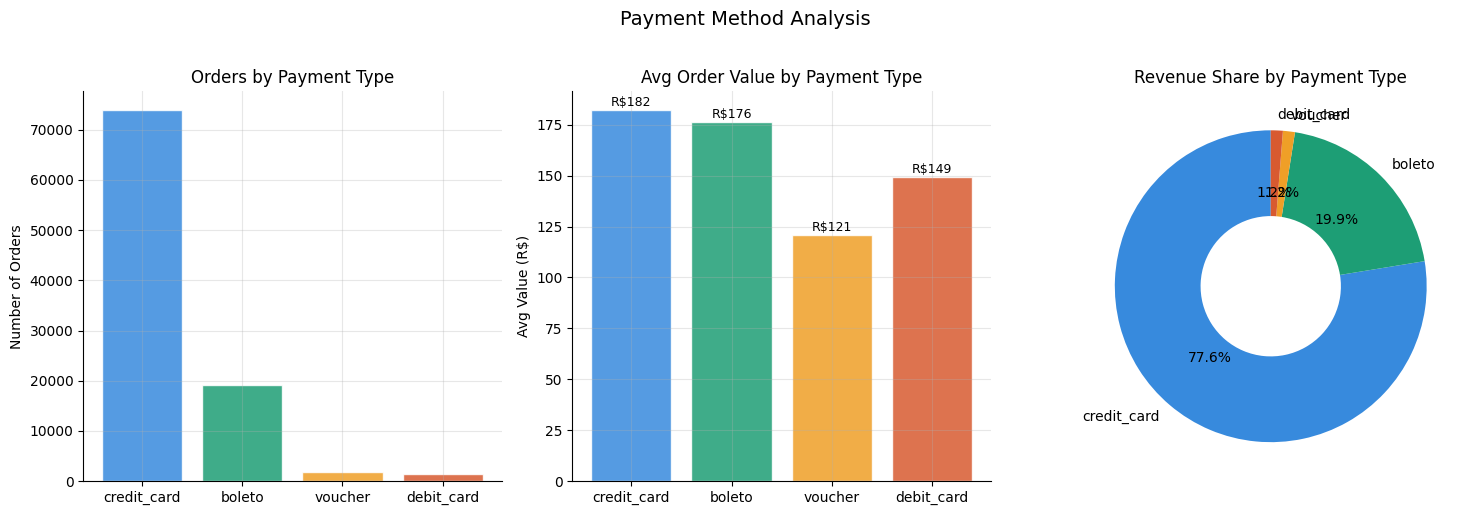

Chart saved!
payment_type  order_count  total_revenue  avg_value  avg_install
 credit_card        73941    15341260.68     182.30         3.64
      boleto        19191     3943080.78     176.33         1.00
     voucher         1861      245141.47     121.00         1.13
  debit_card         1484      246677.51     149.32         1.00


In [10]:
payment_summary = (
    delivered
    .groupby('payment_type')
    .agg(
        order_count   = ('order_id', 'nunique'),
        total_revenue = ('total_payment', 'sum'),
        avg_value     = ('total_payment', 'mean'),
        avg_install   = ('max_installments', 'mean')
    )
    .reset_index()
    .sort_values('order_count', ascending=False)
)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pay_colors = [BLUE, GREEN, AMBER, CORAL]

# Order count
axes[0].bar(payment_summary['payment_type'], payment_summary['order_count'],
            color=pay_colors, edgecolor='white', alpha=0.85)
axes[0].set_title('Orders by Payment Type', fontsize=12)
axes[0].set_ylabel('Number of Orders')

# Avg order value
axes[1].bar(payment_summary['payment_type'], payment_summary['avg_value'],
            color=pay_colors, edgecolor='white', alpha=0.85)
axes[1].set_title('Avg Order Value by Payment Type', fontsize=12)
axes[1].set_ylabel('Avg Value (R$)')
for bar, val in zip(axes[1].patches, payment_summary['avg_value']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'R${val:.0f}', ha='center', fontsize=9)

# Revenue share pie
axes[2].pie(payment_summary['total_revenue'],
            labels=payment_summary['payment_type'],
            autopct='%1.1f%%',
            colors=pay_colors,
            startangle=90,
            wedgeprops=dict(width=0.55))
axes[2].set_title('Revenue Share by Payment Type', fontsize=12)

plt.suptitle('Payment Method Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'payment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(payment_summary.to_string(index=False))

## 11. Chart 8 — Orders by Day of Week & Hour

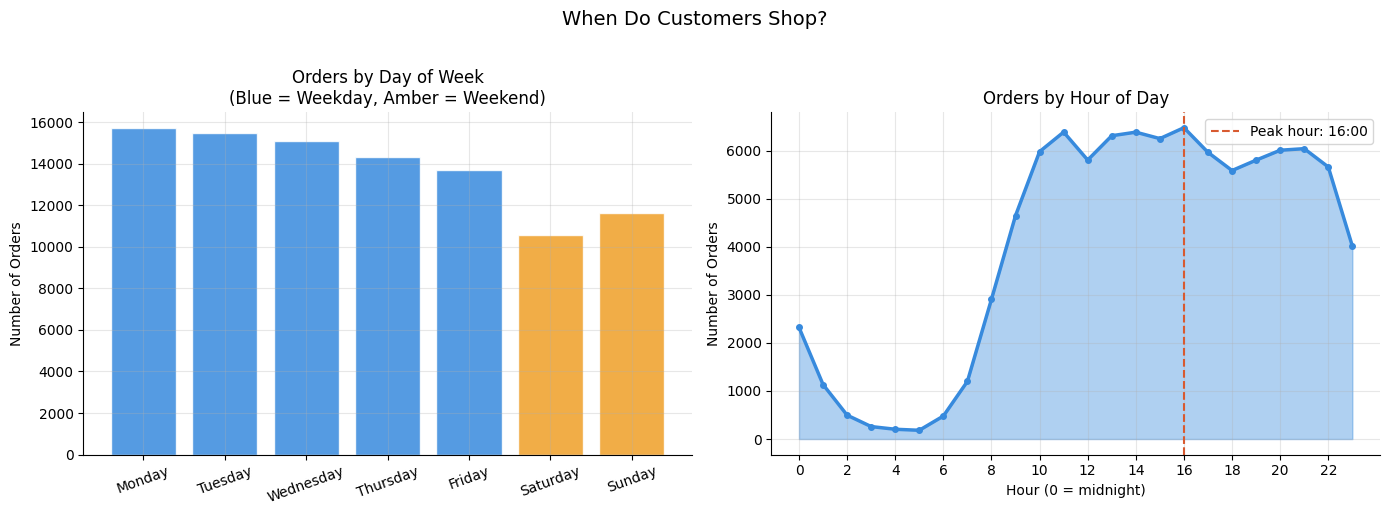

Chart saved!
Peak shopping hour: 16:00
Busiest day: Monday


In [11]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow_counts = (
    delivered
    .drop_duplicates('order_id')
    .groupby('order_dow')
    .size()
    .reindex(dow_order)
)

hour_counts = (
    delivered
    .drop_duplicates('order_id')
    .groupby('order_hour')
    .size()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Day of week
bar_colors_dow = [BLUE if d not in ['Saturday','Sunday'] else AMBER for d in dow_order]
axes[0].bar(dow_counts.index, dow_counts.values,
            color=bar_colors_dow, edgecolor='white', alpha=0.85)
axes[0].set_title('Orders by Day of Week\n(Blue = Weekday, Amber = Weekend)', fontsize=12)
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=20)

# Hour of day
axes[1].fill_between(hour_counts.index, hour_counts.values,
                     color=BLUE, alpha=0.4)
axes[1].plot(hour_counts.index, hour_counts.values,
             color=BLUE, linewidth=2.5, marker='o', markersize=4)
peak_hour = hour_counts.idxmax()
axes[1].axvline(peak_hour, color=CORAL, linewidth=1.5, linestyle='--',
                label=f'Peak hour: {peak_hour}:00')
axes[1].set_title('Orders by Hour of Day', fontsize=12)
axes[1].set_xlabel('Hour (0 = midnight)')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend(fontsize=10)

plt.suptitle('When Do Customers Shop?', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'orders_by_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f'Peak shopping hour: {peak_hour}:00')
print(f'Busiest day: {dow_counts.idxmax()}')

## 12. Chart 9 — Freight Ratio by Category (Top 15)

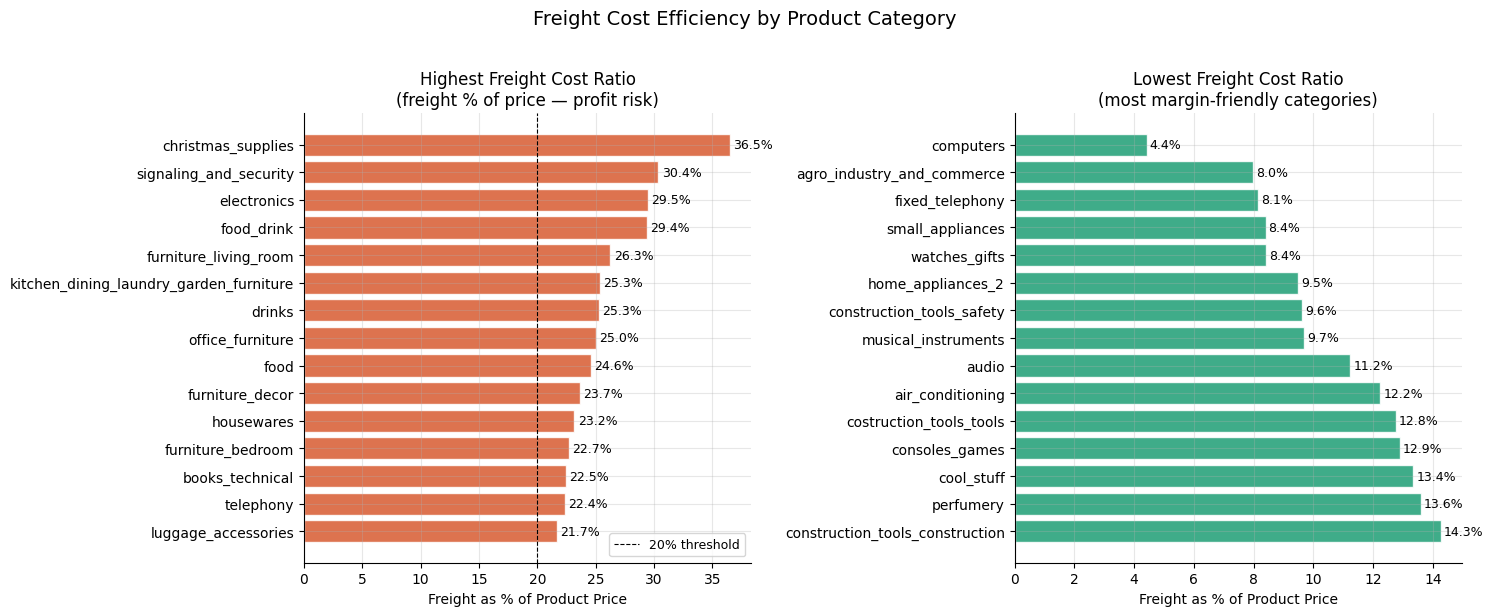

Chart saved!


In [12]:
freight_cat = (
    delivered
    .dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(
        avg_price   = ('price', 'mean'),
        avg_freight = ('freight_value', 'mean'),
        order_count = ('order_id', 'count')
    )
    .reset_index()
)
freight_cat['freight_ratio'] = freight_cat['avg_freight'] / freight_cat['avg_price'] * 100
freight_cat = freight_cat[freight_cat['order_count'] >= 100]

top15_freight = freight_cat.nlargest(15, 'freight_ratio')
low15_freight = freight_cat.nsmallest(15, 'freight_ratio')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Highest freight ratio
axes[0].barh(top15_freight['product_category_name_english'],
             top15_freight['freight_ratio'],
             color=CORAL, alpha=0.85, edgecolor='white')
for i, val in enumerate(top15_freight['freight_ratio']):
    axes[0].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
axes[0].set_title('Highest Freight Cost Ratio\n(freight % of price — profit risk)', fontsize=12)
axes[0].set_xlabel('Freight as % of Product Price')
axes[0].invert_yaxis()
axes[0].axvline(20, color='black', linewidth=0.8, linestyle='--', label='20% threshold')
axes[0].legend(fontsize=9)

# Lowest freight ratio
axes[1].barh(low15_freight['product_category_name_english'],
             low15_freight['freight_ratio'],
             color=GREEN, alpha=0.85, edgecolor='white')
for i, val in enumerate(low15_freight['freight_ratio']):
    axes[1].text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=9)
axes[1].set_title('Lowest Freight Cost Ratio\n(most margin-friendly categories)', fontsize=12)
axes[1].set_xlabel('Freight as % of Product Price')
axes[1].invert_yaxis()

plt.suptitle('Freight Cost Efficiency by Product Category', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'freight_ratio_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')

## 13. Chart 10 — Review Score Distribution & Trend

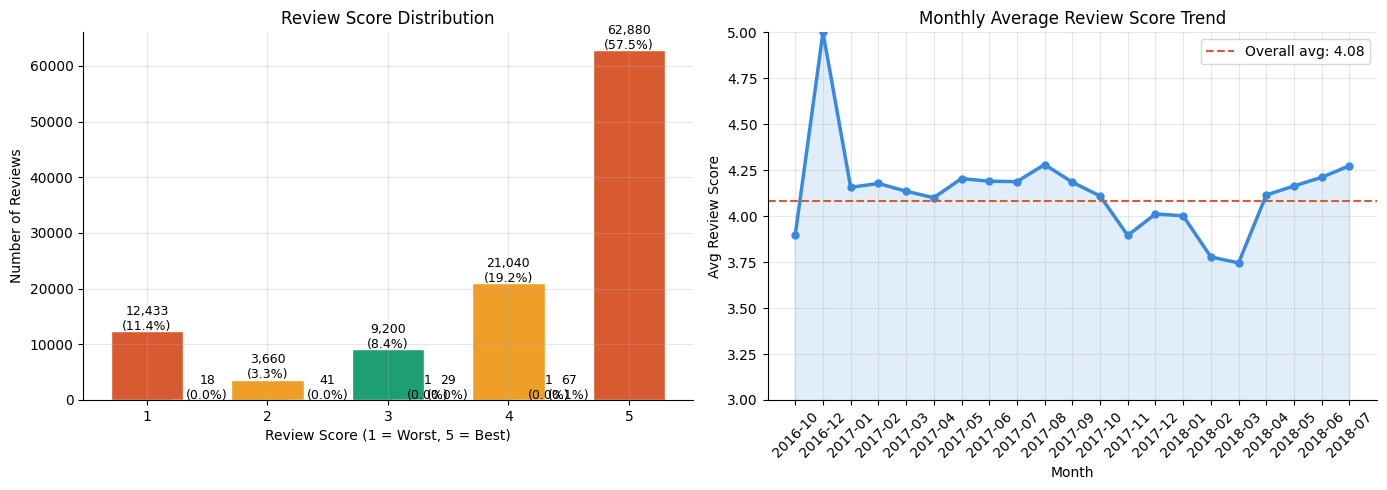

Chart saved!
Overall avg review score : 4.08
% 5-star reviews         : 57.5%
% 1-star reviews         : 11.4%


In [13]:
review_data = delivered.dropna(subset=['review_score'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Review score bar chart
score_counts = review_data['review_score'].value_counts().sort_index()
score_colors = [CORAL, CORAL, AMBER, GREEN, GREEN]
bars = axes[0].bar(score_counts.index, score_counts.values,
                   color=score_colors, edgecolor='white', width=0.6)
for bar, val in zip(bars, score_counts.values):
    pct = val / score_counts.sum() * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=9)
axes[0].set_title('Review Score Distribution', fontsize=12)
axes[0].set_xlabel('Review Score (1 = Worst, 5 = Best)')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Monthly avg review trend
monthly_review = (
    review_data
    .groupby('order_month_str')['review_score']
    .mean()
    .reset_index()
    .sort_values('order_month_str')
    .iloc[1:-1]
)
axes[1].plot(monthly_review['order_month_str'], monthly_review['review_score'],
             color=BLUE, linewidth=2.5, marker='o', markersize=5)
axes[1].fill_between(monthly_review['order_month_str'],
                     monthly_review['review_score'],
                     alpha=0.15, color=BLUE)
axes[1].axhline(review_data['review_score'].mean(), color=CORAL,
                linewidth=1.5, linestyle='--',
                label=f"Overall avg: {review_data['review_score'].mean():.2f}")
axes[1].set_title('Monthly Average Review Score Trend', fontsize=12)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Review Score')
axes[1].set_ylim(3, 5)
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'review_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f"Overall avg review score : {review_data['review_score'].mean():.2f}")
print(f"% 5-star reviews         : {(score_counts[5]/score_counts.sum()*100):.1f}%")
print(f"% 1-star reviews         : {(score_counts[1]/score_counts.sum()*100):.1f}%")

## 14. Chart 11 — Seller Performance Overview

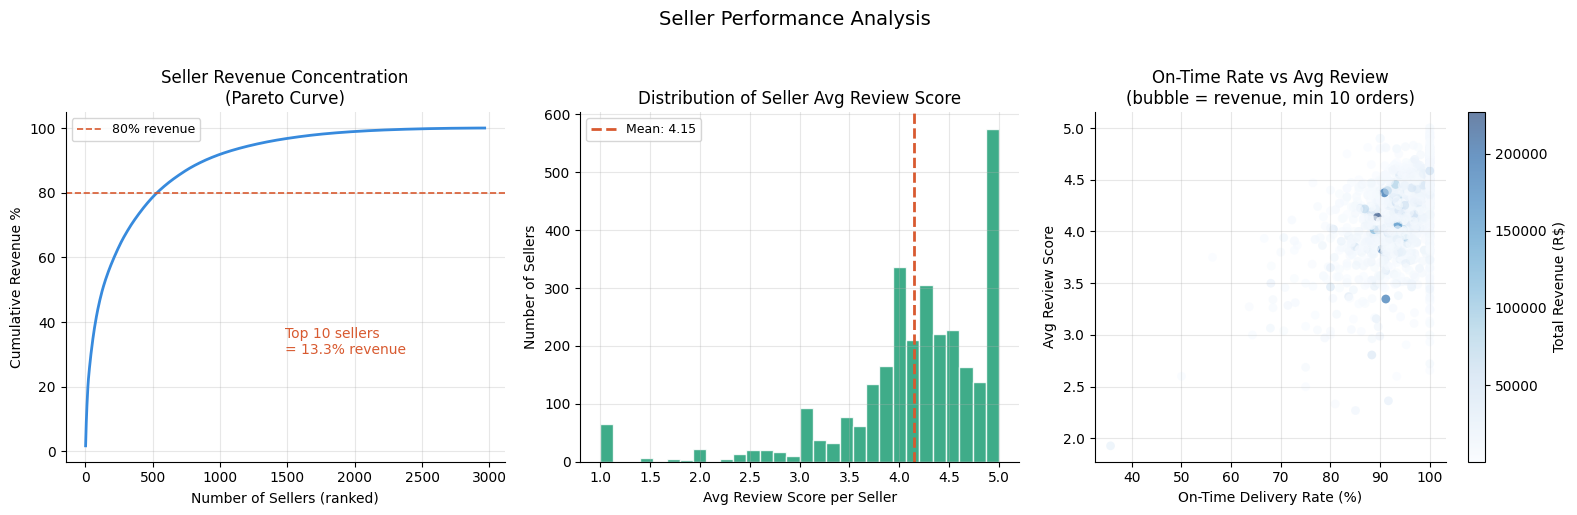

Chart saved!
Total sellers analysed : 2,965
Top 10 sellers revenue : 13.3% of total


In [14]:
seller_perf = (
    delivered
    .groupby('seller_id')
    .agg(
        total_revenue  = ('price', 'sum'),
        order_count    = ('order_id', 'nunique'),
        avg_review     = ('review_score', 'mean'),
        avg_delay      = ('delivery_delay_days', 'mean'),
        on_time_rate   = ('is_late', lambda x: (1 - x.mean()) * 100)
    )
    .reset_index()
    .dropna()
)

# Revenue concentration
seller_perf_sorted = seller_perf.sort_values('total_revenue', ascending=False).reset_index(drop=True)
seller_perf_sorted['cumulative_pct'] = seller_perf_sorted['total_revenue'].cumsum() / seller_perf_sorted['total_revenue'].sum() * 100
top10_revenue_pct = seller_perf_sorted.head(10)['total_revenue'].sum() / seller_perf_sorted['total_revenue'].sum() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pareto curve
axes[0].plot(range(1, len(seller_perf_sorted)+1),
             seller_perf_sorted['cumulative_pct'],
             color=BLUE, linewidth=2)
axes[0].axhline(80, color=CORAL, linewidth=1.2, linestyle='--', label='80% revenue')
axes[0].set_title('Seller Revenue Concentration\n(Pareto Curve)', fontsize=12)
axes[0].set_xlabel('Number of Sellers (ranked)')
axes[0].set_ylabel('Cumulative Revenue %')
axes[0].legend(fontsize=9)
axes[0].text(len(seller_perf_sorted)*0.5, 30,
             f'Top 10 sellers\n= {top10_revenue_pct:.1f}% revenue',
             fontsize=10, color=CORAL)

# Review score distribution across sellers
axes[1].hist(seller_perf['avg_review'].dropna(), bins=30,
             color=GREEN, edgecolor='white', alpha=0.85)
axes[1].axvline(seller_perf['avg_review'].mean(), color=CORAL,
                linewidth=2, linestyle='--',
                label=f"Mean: {seller_perf['avg_review'].mean():.2f}")
axes[1].set_title('Distribution of Seller Avg Review Score', fontsize=12)
axes[1].set_xlabel('Avg Review Score per Seller')
axes[1].set_ylabel('Number of Sellers')
axes[1].legend(fontsize=9)

# Review vs on-time rate scatter
scatter_data = seller_perf[seller_perf['order_count'] >= 10]
sc = axes[2].scatter(scatter_data['on_time_rate'], scatter_data['avg_review'],
                     c=scatter_data['total_revenue'], cmap='Blues',
                     alpha=0.6, s=40, edgecolors='none')
plt.colorbar(sc, ax=axes[2], label='Total Revenue (R$)')
axes[2].set_title('On-Time Rate vs Avg Review\n(bubble = revenue, min 10 orders)', fontsize=12)
axes[2].set_xlabel('On-Time Delivery Rate (%)')
axes[2].set_ylabel('Avg Review Score')

plt.suptitle('Seller Performance Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS_PATH + 'seller_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved!')
print(f'Total sellers analysed : {len(seller_perf):,}')
print(f'Top 10 sellers revenue : {top10_revenue_pct:.1f}% of total')

## 15. EDA Summary — All Insights in One Place

In [15]:
print('=' * 60)
print('         EDA COMPLETE — KEY FINDINGS SUMMARY')
print('=' * 60)

print(f"""
REVENUE & GROWTH
  Total revenue (delivered orders) : R$ {total_revenue:,.0f}
  Total orders (delivered)         : {total_orders:,}
  Avg order value                  : R$ {avg_order_value:.2f}
  Peak month                       : Nov 2017 (Black Friday spike)

GEOGRAPHY
  SP state revenue share           : {state_rev[state_rev['customer_state']=='SP']['revenue_pct'].values[0]}%
  Top 3 states by revenue          : SP, RJ, MG
  Worst delivery delay states      : Northern states (AM, RR, AP)

DELIVERY PERFORMANCE
  On-time delivery rate            : {on_time_count/(on_time_count+late_count)*100:.1f}%
  Avg delivery time                : {avg_delivery_days:.1f} days
  Avg delay (late orders)          : {delivery_data[delivery_data['delivery_delay_days']>0]['delivery_delay_days'].mean():.1f} days

CUSTOMER SATISFACTION
  Overall avg review score         : {avg_review:.2f} / 5.0
  On-time delivery avg review      : {on_time_reviews.mean():.2f}
  Late delivery avg review         : {late_reviews.mean():.2f}
  Review impact of delay           : {on_time_reviews.mean() - late_reviews.mean():.2f} stars lost per late order
  Statistical significance         : p = {p_val:.4f} (highly significant)

SELLERS
  Total active sellers             : {total_sellers:,}
  Top 10 sellers revenue share     : {top10_revenue_pct:.1f}%

CHARTS SAVED TO outputs/
  01 monthly_revenue_trend.png
  02 order_status_breakdown.png
  03 top15_categories_revenue.png
  04 revenue_and_delay_by_state.png
  05 delivery_performance.png
  06 review_vs_delay.png
  07 payment_analysis.png
  08 orders_by_time.png
  09 freight_ratio_by_category.png
  10 review_score_analysis.png
  11 seller_performance.png
""")
print('=' * 60)
print('Next → Notebook 03: Profit Analysis')
print('=' * 60)

         EDA COMPLETE — KEY FINDINGS SUMMARY

REVENUE & GROWTH
  Total revenue (delivered orders) : R$ 19,776,160
  Total orders (delivered)         : 96,478
  Avg order value                  : R$ 204.98
  Peak month                       : Nov 2017 (Black Friday spike)

GEOGRAPHY
  SP state revenue share           : 37.4%
  Top 3 states by revenue          : SP, RJ, MG
  Worst delivery delay states      : Northern states (AM, RR, AP)

DELIVERY PERFORMANCE
  On-time delivery rate            : 93.7%
  Avg delivery time                : 12.0 days
  Avg delay (late orders)          : 8.4 days

CUSTOMER SATISFACTION
  Overall avg review score         : 4.08 / 5.0
  On-time delivery avg review      : 4.21
  Late delivery avg review         : 2.26
  Review impact of delay           : 1.95 stars lost per late order
  Statistical significance         : p = 0.0000 (highly significant)

SELLERS
  Total active sellers             : 2,970
  Top 10 sellers revenue share     : 13.3%

CHARTS SAVED T

---
## Next Step → Notebook 03: Profit Analysis

Load the master dataset in the next notebook with:
```python
master = pd.read_csv('../data/master_olist.csv')
```